<a href="https://colab.research.google.com/github/katsoulakisstelios/gdp_prediction/blob/main/gdp_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet


import random
np.random.seed(42)
random.seed(42)

from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)
matplotlib.style.use('ggplot')

/tmp/ipykernel_63006/460687440.py:21: StaleDataWarning: CPI data is out of date. To accurately inflate to today's dollars, you must run `cpi.update()`.
  import cpi


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/gdp.csv")

In [ ]:
population_df = pd.read_csv("/content/drive/MyDrive/population.csv")

In [ ]:
df = pd.merge(df,population_df,how='left',on=['Country Name','Country Code','Year'])

In [ ]:
df['GDP/Capita'] = df['Value']/df['Population']

In [ ]:
df.head()

,Country Name,Country Code,Year,Value,Population,GDP/Capita
0,Afghanistan,AFG,2000,3.521418e+09,20130327.0,174.930991
1,Afghanistan,AFG,2001,2.813572e+09,20284307.0,138.706822
2,Afghanistan,AFG,2002,3.825701e+09,21378117.0,178.954088
3,Afghanistan,AFG,2003,4.520947e+09,22733049.0,198.871116
4,Afghanistan,AFG,2004,5.224897e+09,23560654.0,221.763654


In [ ]:
df.tail()

,Country Name,Country Code,Year,Value,Population,GDP/Capita
13974,Zimbabwe,ZWE,2019,2.183223e+10,15271368.0,1429.618809
13975,Zimbabwe,ZWE,2020,2.150970e+10,15526888.0,1385.319351
13976,Zimbabwe,ZWE,2021,2.837124e+10,15797210.0,1795.965152
13977,Zimbabwe,ZWE,2022,2.736663e+10,16069056.0,1703.063774
13978,Zimbabwe,ZWE,2023,2.653827e+10,16340822.0,1624.047646


In [ ]:
print("Missing values by feature before cleaning:")
print(df.isnull().sum())

Missing values by feature before cleaning:
Country Name    0
Country Code    0
Year            0
Value           0
Population      0
GDP/Capita      0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Country Name'].value_counts()

,count
Country Name,
Zimbabwe,64
Zambia,64
Africa Eastern and Southern,64
Africa Western and Central,64
Turkiye,64
Trinidad and Tobago,64
Benin,64
Togo,64
Thailand,64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979 entries, 0 to 13978
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  13979 non-null  object 
 1   Country Code  13979 non-null  object 
 2   Year          13979 non-null  int64  
 3   Value         13979 non-null  float64
 4   Population    13979 non-null  float64
 5   GDP/Capita    13979 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 655.4+ KB


In [ ]:
df.columns

Index(['Country Name', 'Country Code', 'Year', 'Value', 'Population',
       'GDP/Capita'],
      dtype='object')

In [ ]:
df['Country Name'].nunique()

262

In [ ]:
df['Country Name'].unique()

array(['Afghanistan', 'Africa Eastern and Southern',
       'Africa Western and Central', 'Albania', 'Algeria',
       'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda',
       'Arab World', 'Argentina', 'Armenia', 'Aruba', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Caribbean small states', 'Cayman Islands',
       'Central African Republic', 'Central Europe and the Baltics',
       'Chad', 'Channel Islands', 'Chile', 'China', 'Colombia', 'Comoros',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic',
       'Early-demogr

In [ ]:
print(df['Year'].min())
print(df['Year'].max())

1960
2023


We notice that in the dataset for many countries there is information from 1960 to 2023. That is to say for 64 years. However, there are some countries that do not have data for certain time periods.

It is also interesting that the dataset, beyond the countries of the world, the dataset also includes information about regions, international organizations, overseas territories and others. In the dataset there are 262 countries, regions organizations and others.

However, since this project also aims to help predict how a country is going to develop in the following years, it is really important to find how the average person's life is going to change in the following years. That is why it is really important to also find other indexes beyond GDP. That is why I decided to also create a GDP / Capita column.

# Exploratory Data Analysis

<img src="https://blog.naveenchandra.co.in/wp-content/uploads/2023/08/eda.png">

In [ ]:
df.shape

(13979, 6)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,13979.0,1.994673e+03,1.773141e+01,1960.000000,1.980000e+03,1.996000e+03,2.010000e+03,2.023000e+03
Value,13979.0,1.207380e+12,5.537517e+12,11502.632645,2.233880e+09,1.672591e+10,2.058542e+11,1.054350e+14
Population,13979.0,2.573211e+08,7.763089e+08,5663.000000,1.775672e+06,8.668067e+06,6.438646e+07,8.061876e+09
GDP/Capita,13979.0,8.475376e+03,1.697329e+04,0.002425,5.792916e+02,1.935293e+03,7.960194e+03,2.256300e+05


## GDP Statistics

In [ ]:
df_2023 = df[df['Year'] == 2023]
df_2023_sorted = df_2023.sort_values(by='Value', ascending=False)
print("Top 10 Countries by GDP in 2023:")
df_top_10_gdp = df_2023_sorted.head(10)

Top 10 Countries by GDP in 2023:


The dataset contains several non-country entities, such as economic unions, that currently occupy the top 10 GDP rankings. To focus our analysis strictly on national GDP growth, these non-country entities must be excluded.

In [ ]:
non_country_entities = [
    'World', 'High income', 'Low income', 'OECD members', 'Post-demographic dividend',
    'IDA & IBRD total', 'IBRD only', 'Low & middle income', 'Middle income',
    'East Asia & Pacific', 'North America', 'European Union', 'Euro area',
    'Europe & Central Asia', 'Sub-Saharan Africa', 'Latin America & Caribbean',
    'South Asia', 'Early-demographic dividend', 'Pre-demographic dividend',
    'Least developed countries: UN classification', 'Fragile and conflict affected situations',
    'Africa Eastern and Southern', 'Africa Western and Central', 'Arab World',
    'Caribbean small states', 'Central Europe and the Baltics', 'Channel Islands',
    'East Asia & Pacific (IDA & IBRD countries)', 'East Asia & Pacific (excluding high income)',
    'Europe & Central Asia (IDA & IBRD countries)', 'Europe & Central Asia (excluding high income)',
    'Heavily indebted poor countries (HIPC)', 'IDA blend', 'IDA only', 'IDA total',
    'Late-demographic dividend', 'Latin America & Caribbean (excluding high income)',
    'Latin America & the Caribbean (IDA & IBRD countries)', 'Lower middle income',
    'Middle East & North Africa', 'Middle East & North Africa (IDA & IBRD countries)',
    'Middle East & North Africa (excluding high income)', 'North Africa',
    'Northern Mariana Islands', 'Other small states', 'Pacific island small states',
    'Small states', 'South Asia (IDA & IBRD)', 'Sub-Saharan Africa (IDA & IBRD countries)',
    'Sub-Saharan Africa (excluding high income)', 'Upper middle income'
]

df_2023_countries = df_2023_sorted[~df_2023_sorted['Country Name'].isin(non_country_entities)].copy()
top_10_countries_gdp = df_2023_countries.head(10)
top_30_countries_gdp = df_2023_countries.head(30)

# Pre-calculate the display value in trillions
top_30_countries_gdp['Value_Trillions'] = top_30_countries_gdp['Value'] / 1e12

print("Top 30 Countries by GDP in 2023 (excluding non-country entities):")
display(top_30_countries_gdp[['Country Name', 'Value', 'Value_Trillions']].head())

fig = px.bar(
    top_30_countries_gdp,
    x='Country Code',
    y='Value',
    title='Top 30 Countries by GDP in 2023 (Trillions USD)',
    labels={'Value': 'GDP (current USD)', 'Country Code': 'Country Code', 'Value_Trillions': 'GDP (Trillions)'},
    hover_data=['Country Name'],
    text='Value_Trillions' # Use the pre-calculated column
)

# Format the text labels to 2 decimal places
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.show()

Top 30 Countries by GDP in 2023 (excluding non-country entities):


,Country Name,Value,Value_Trillions
13403,United States,2.736094e+13,27.360935
2363,China,1.779478e+13,17.794782
4625,Germany,4.456081e+12,4.456081
6463,Japan,4.212945e+12,4.212945
5933,India,3.549919e+12,3.549919


In [ ]:
country_names = top_10_countries_gdp['Country Name'].tolist()
top_5_countries = country_names[:5]
next_5_countries = country_names[5:]

print("Top 5 Countries:", top_5_countries)
print("Next 5 Countries:", next_5_countries)

Top 5 Countries: ['United States', 'China', 'Germany', 'Japan', 'India']
Next 5 Countries: ['United Kingdom', 'France', 'Italy', 'Brazil', 'Canada']


In [ ]:
df_top_5_all_years = df[df['Country Name'].isin(top_5_countries)]
df_next_5_all_years = df[df['Country Name'].isin(next_5_countries)]

print("DataFrame for Top 5 Economies (all years):")
print(df_top_5_all_years.head())
print("\nDataFrame for Next 5 Economies (all years):")
print(df_next_5_all_years.head())

DataFrame for Top 5 Economies (all years):
     Country Name Country Code  Year         Value   Population  GDP/Capita
2300        China          CHN  1960  5.971625e+10  667070000.0   89.520214
2301        China          CHN  1961  5.005669e+10  660330000.0   75.805561
2302        China          CHN  1962  4.720919e+10  665770000.0   70.909152
2303        China          CHN  1963  5.070661e+10  682335000.0   74.313372
2304        China          CHN  1964  5.970813e+10  698355000.0   85.498243

DataFrame for Next 5 Economies (all years):
     Country Name Country Code  Year         Value   Population   GDP/Capita
1489       Brazil          BRA  1989  4.255953e+11  146502972.0  2905.028510
1490       Brazil          BRA  1990  3.849598e+11  149143223.0  2581.141874
1491       Brazil          BRA  1991  3.425341e+11  151724256.0  2257.609297
1492       Brazil          BRA  1992  3.281919e+11  154275079.0  2127.316427
1493       Brazil          BRA  1993  3.682920e+11  156794577.0  2348.8

In [ ]:
# Sort the list of countries by their 2023 value to ensure the legend order matches the visual ranking
sorted_top_5 = df_top_5_all_years[df_top_5_all_years['Year'] == 2023].sort_values('Value', ascending=False)['Country Name'].tolist()

fig_top_5 = px.line(
    df_top_5_all_years,
    x='Year',
    y='Value',
    color='Country Name',
    category_orders={'Country Name': sorted_top_5},
    title='GDP Evolution Over Time for Top 5 Economies',
    labels={'Value': 'GDP (current USD)', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code']
)
fig_top_5.show()

In [ ]:
display(df_top_5_all_years[df_top_5_all_years['Country Name'] == 'United States'].sort_values('Year').tail())
print(f"Max GDP for US in dataset: {df_top_5_all_years[df_top_5_all_years['Country Name'] == 'United States']['Value'].max():.2e}")
print(f"Max GDP for China in dataset: {df_top_5_all_years[df_top_5_all_years['Country Name'] == 'China']['Value'].max():.2e}")

,Country Name,Country Code,Year,Value,Population,GDP/Capita
13399,United States,USA,2019,2.152140e+13,328329953.0,65548.070785
13400,United States,USA,2020,2.132295e+13,331526933.0,64317.398913
13401,United States,USA,2021,2.359403e+13,332048977.0,71055.876194
13402,United States,USA,2022,2.574411e+13,333271411.0,77246.673883
13403,United States,USA,2023,2.736094e+13,334914895.0,81695.187071


Max GDP for US in dataset: 2.74e+13
Max GDP for China in dataset: 1.79e+13


*   As expected the economy of the United States has grown steadily over the years and has not extreme increases or decreases in its GDP even in the 2009 market crash and the 2020 COVID pandemic.


*   China's economy up to 2000 had not grown extremely and its GDP was around India's. However, ever since then it has grown exponentially and now China is the second biggest economy in the world only behind the United States.


*   Japan's GDP has remained the same ever since the 1990s and was, up until recently, in the top 3 global economies, when it was surpassed by Germany.


*  Even though Germany was at a large degree destroyed after World War 2 ever since it has managed to grow steadily and recently has even become the 3rd largest economy in the world.



*   Up until the 2000s India's GDP was relatively small compared to its population. However, over the past 25 years, it has grown exponentially and has managed to become the 5th largest economy in the world.



In [ ]:
fig_next_5 = px.line(
    df_next_5_all_years,
    x='Year',
    y='Value',
    color='Country Name',
    title='GDP Evolution Over Time for Next 5 Economies',
    hover_data=['Country Code']
)
fig_next_5.show()

In [ ]:
df_growth = df.copy()
df_growth['Growth_Rate'] = df_growth.groupby('Country Name')['Value'].pct_change() * 100
print(df_growth.head())


  Country Name Country Code  Year         Value  Population  GDP/Capita  \
0  Afghanistan          AFG  2000  3.521418e+09  20130327.0  174.930991   
1  Afghanistan          AFG  2001  2.813572e+09  20284307.0  138.706822   
2  Afghanistan          AFG  2002  3.825701e+09  21378117.0  178.954088   
3  Afghanistan          AFG  2003  4.520947e+09  22733049.0  198.871116   
4  Afghanistan          AFG  2004  5.224897e+09  23560654.0  221.763654   

   Growth_Rate  
0          NaN  
1   -20.101172  
2    35.973125  
3    18.173017  
4    15.570851  


In [ ]:
def calculate_cagr(country_name):
    # Filter data for the specific country
    country_data = df[df['Country Name'] == country_name].sort_values('Year')

    if len(country_data) < 2:
        return None

    # Get first and last available data points
    first_val = country_data.iloc[0]['Value']
    last_val = country_data.iloc[-1]['Value']
    first_year = country_data.iloc[0]['Year']
    last_year = country_data.iloc[-1]['Year']

    num_years = last_year - first_year

    # Calculate CAGR
    cagr = (pow(last_val / first_val, 1 / num_years) - 1) * 100

    print(f"CAGR for {country_name} ({first_year}-{last_year}): {cagr:.2f}%")
    return cagr
for country in df_top_5_all_years['Country Name'].unique():
  calculate_cagr(country)

CAGR for China (1960-2023): 9.46%
CAGR for Germany (1960-2023): 6.50%
CAGR for India (1960-2023): 7.51%
CAGR for Japan (1960-2023): 7.38%
CAGR for United States (1960-2023): 6.42%


In [ ]:
volatility_df = df_growth.groupby('Country Name')['Growth_Rate'].std().reset_index()
volatility_df.columns = ['Country Name', 'Volatility']
print(volatility_df.head())

                  Country Name  Volatility
0                  Afghanistan   16.279669
1  Africa Eastern and Southern    9.804650
2   Africa Western and Central   18.434113
3                      Albania   22.493740
4                      Algeria   14.293690


In [ ]:
volatility_top_10_gdp = volatility_df[volatility_df['Country Name'].isin(top_10_countries_gdp['Country Name'])]
print(volatility_top_10_gdp)

       Country Name  Volatility
29           Brazil   18.379054
37           Canada    7.345256
45            China    9.882056
82           France   10.577643
87          Germany   10.940162
109           India    8.586475
116           Italy   10.715690
118           Japan   12.678165
248  United Kingdom    9.821913
249   United States    2.984865


In [ ]:
fig_volatility = px.bar(
    volatility_top_10_gdp,
    x='Country Name',
    y='Volatility',
    title='GDP Volatility of Top 10 Economies',
    hover_data=['Volatility']
)
fig_volatility.show()

In [ ]:
volatility_top_10 = volatility_df.sort_values(by='Volatility', ascending=False).head(11)
volatility_top_10 = volatility_top_10[volatility_top_10["Country Name"] != "Georgia"]
print(volatility_top_10)

             Country Name  Volatility
68      Equatorial Guinea   58.949959
48       Congo, Dem. Rep.   57.164601
112                  Iraq   57.035657
15             Azerbaijan   54.192945
247  United Arab Emirates   37.105005
181                  Oman   35.173316
196                 Qatar   32.264662
175               Nigeria   31.229921
7                  Angola   29.436535
203          Saudi Arabia   28.939711


In [ ]:
fig_volatility_top_10 = px.bar(
    volatility_top_10,
    x='Country Name',
    y='Volatility',
    title='Top 10 Countries with Highest GDP Volatility',
    labels={'Volatility': 'GDP Volatility', 'Country Name': 'Country'},
    hover_data=['Volatility']
)
fig_volatility_top_10.show()

Some of the countries with the highest GDP volatility are actually from the Middle East. This is to be expected as, because of the discovery of oil or natural gas, these countries grew exponentially and thus their volatility is very high. Azerbaijan is also a country in which large amounts of natural gas were recently discovered, thus explaining its high volatility. The rest of the Top 10 Most Volatile Countries are probably not very financially stable and thus have large changes in their GDP.

In [ ]:
df_georgia = df[df['Country Name'] == 'Georgia']

fig_georgia = px.line(
    df_georgia,
    x='Year',
    y='Value',
    title='GDP Evolution Over Time for Georgia',
    hover_data=['Country Code']
)
fig_georgia.show()

Georgia is actually the country with the highest volatility among the countries in the dataset. However, it was not included in the above bar chart since its volatility was much higher than that of the other countries. This is because between the years 1989 and 1990, Georgia's GDP grew from around 15 thousand to 7.5 billion.

## GDP / Capita Statistics

However, it is really important that we understand how the conditions for people in each country are. This is something that the GDP does not show and that is why we should also consider other metrics, such as GDP/Capita.

In [ ]:
df_2023_sorted_per_capita = df_2023.sort_values(by='GDP/Capita',ascending=False)
print("Top 10 Countries by GDP / Capita:")
df_2023_sorted_per_capita.head(10)

Top 10 Countries by GDP / Capita:


,Country Name,Country Code,Year,Value,Population,GDP/Capita
7697,Luxembourg,LUX,2023,8.575501e+10,666430.0,128678.189943
6180,Ireland,IRL,2023,5.456295e+11,5307600.0,102801.539378
12445,Switzerland,CHE,2023,8.849404e+11,8888093.0,99564.710026
9634,Norway,NOR,2023,4.855133e+11,5519594.0,87961.780614
11238,Singapore,SGP,2023,5.014275e+11,5917648.0,84734.255921
13403,United States,USA,2023,2.736094e+13,334914895.0,81695.187071
5869,Iceland,ISL,2023,3.102003e+10,393349.0,78861.348531
9517,North America,NAC,2023,2.950930e+13,375077354.0,78675.227329
7739,"Macao SAR, China",MAC,2023,4.706184e+10,678800.0,69330.942422
2939,Denmark,DNK,2023,4.041988e+11,5946952.0,67967.381869


In [ ]:
df_2023_countries_by_gdp_per_capita = df_2023_sorted_per_capita[~df_2023_sorted_per_capita['Country Name'].isin(non_country_entities)]
top_10_countries_gdp_per_capita = df_2023_countries_by_gdp_per_capita.head(10)

print("Top 10 Countries by GDP / Capita in 2023 (excluding non-country entities):")
print(top_10_countries_gdp_per_capita)

fig = px.bar(
    top_10_countries_gdp_per_capita,
    x='Country Name',
    y='GDP/Capita',
    title='Top 10 Countries by GDP / Capita in 2023',
    labels={'Country Name': 'Country'},
    hover_data=['Country Code']
)
fig.show()

Top 10 Countries by GDP / Capita in 2023 (excluding non-country entities):
           Country Name Country Code  Year         Value   Population  \
7697         Luxembourg          LUX  2023  8.575501e+10     666430.0   
6180            Ireland          IRL  2023  5.456295e+11    5307600.0   
12445       Switzerland          CHE  2023  8.849404e+11    8888093.0   
9634             Norway          NOR  2023  4.855133e+11    5519594.0   
11238         Singapore          SGP  2023  5.014275e+11    5917648.0   
13403     United States          USA  2023  2.736094e+13  334914895.0   
5869            Iceland          ISL  2023  3.102003e+10     393349.0   
7739   Macao SAR, China          MAC  2023  4.706184e+10     678800.0   
2939            Denmark          DNK  2023  4.041988e+11    5946952.0   
642           Australia          AUS  2023  1.723827e+12   26658948.0   

          GDP/Capita  
7697   128678.189943  
6180   102801.539378  
12445   99564.710026  
9634    87961.780614  
11238 

Most of the countries with the highest GDP/Capita have small populations and relatively high GDPs. The only outliers here are Australia and the US, which, even though they have a large population, their GDP is many times larger and thus their GDP/Capita is also very high.

## Greece Growth Over Time

In [ ]:
df_greece = df[df['Country Name'] == 'Greece']

fig_greece = px.line(
    df_greece,
    x='Year',
    y='Value',
    title='GDP Evolution Over Time for Greece',
    hover_data=['Country Code']
)
fig_greece.show()

fig_greece_per_capita = px.line(
    df_greece,
    x='Year',
    y='GDP/Capita',
    title='GDP / Capita Evolution Over Time for Greece',
    hover_data=['Country Code']
)
fig_greece_per_capita.show()

fig_greece_population = px.line(
    df_greece,
    x='Year',
    y='Population',
    title='Population Growth of Greece',
    hover_data=['Country Code']
)
fig_greece_population.show()

As can be seen from both GDP and GDP/Capita graphs, Greece's economy was severely
affected by the 2008 financial crisis and has not fully recovered since. This can be
attributed to the fact that before the crisis the Greek government had accumulated
large debts, and when the crisis hit, it lost access to financial markets and was
forced into a severe austerity program, which caused GDP to collapse by nearly 25%.

In [ ]:
df_greece_eu = df[df['Country Name'].isin(['Greece', 'European Union'])]
print(df_greece_eu.head())

        Country Name Country Code  Year         Value   Population  \
3967  European Union          EUU  1960  2.850731e+11  357710931.0   
3968  European Union          EUU  1961  3.168704e+11  360682976.0   
3969  European Union          EUU  1962  3.502218e+11  363708887.0   
3970  European Union          EUU  1963  3.848216e+11  366840786.0   
3971  European Union          EUU  1964  4.268577e+11  370055037.0   

       GDP/Capita  
3967   796.936935  
3968   878.528878  
3969   962.917946  
3970  1049.015365  
3971  1153.498007  


In [ ]:
fig_gdp_per_capita_comparison = px.line(
    df_greece_eu,
    x='Year',
    y='GDP/Capita',
    color='Country Name',
    title='GDP/Capita Comparison: Greece vs. European Union Over Time',
    hover_data=['Country Code']
)
fig_gdp_per_capita_comparison.show()

# ML Forecasting

## Linear Forecasting

Linear Regression Results for United States:
Mean Squared Error (MSE): 31470576573301327757574144.0000
Mean Absolute Error (MAE): 5071892674139.42
Mean Absolute Percentage Error (MAPE): 23.85%


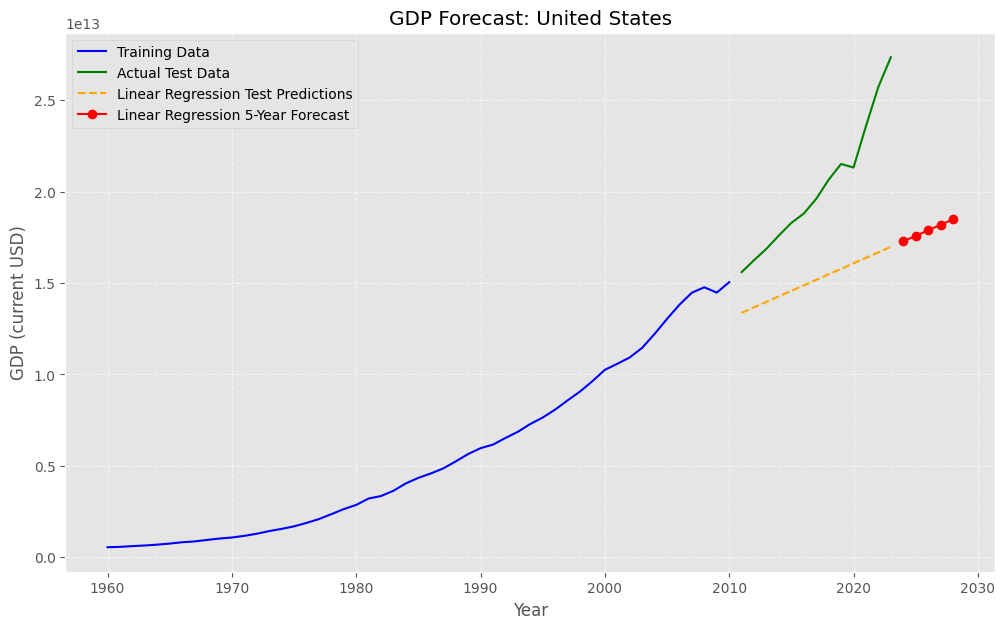

0.23854934130312636

In [ ]:
def linear_reg(country, plot=True):
  df_linear_reg= df[df['Country Name'] == country]
  df_linear_reg = df_linear_reg.sort_values(by='Year')
  X = df_linear_reg[['Year']].values
  y = df_linear_reg['Value'].values

  train_size = int(len(df_linear_reg) * 0.8)
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]
  model = LinearRegression()
  model.fit(X_train.reshape(-1, 1), y_train)
  y_pred_test = model.predict(X_test.reshape(-1, 1))
  linear_mape = mean_absolute_percentage_error(y_test, y_pred_test)

  if plot:
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    print(f"Linear Regression Results for {country}:") # Corrected print statement
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {linear_mape*100:.2f}%")

    last_year = df_linear_reg['Year'].max()
    future_years = np.array([[last_year + i] for i in range(1, 6)])
    future_forecast = model.predict(future_years.reshape(-1, 1))
    plt.figure(figsize=(12, 7))
    plt.plot(X_train, y_train, label='Training Data', color='blue')
    plt.plot(X_test, y_test, label='Actual Test Data', color='green')
    plt.plot(X_test, y_pred_test, label='Linear Regression Test Predictions', color='orange', linestyle='--')
    plt.plot(future_years, future_forecast, label='Linear Regression 5-Year Forecast', color='red', linestyle='-', marker='o')

    plt.title(f"GDP Forecast: {country}")
    plt.xlabel("Year")
    plt.ylabel("GDP (current USD)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

  return linear_mape

linear_reg("United States")

Linear Regression Results for Switzerland:
Mean Squared Error (MSE): 42639931615953771560960.0000
Mean Absolute Error (MAE): 203192360220.93
Mean Absolute Percentage Error (MAPE): 27.36%


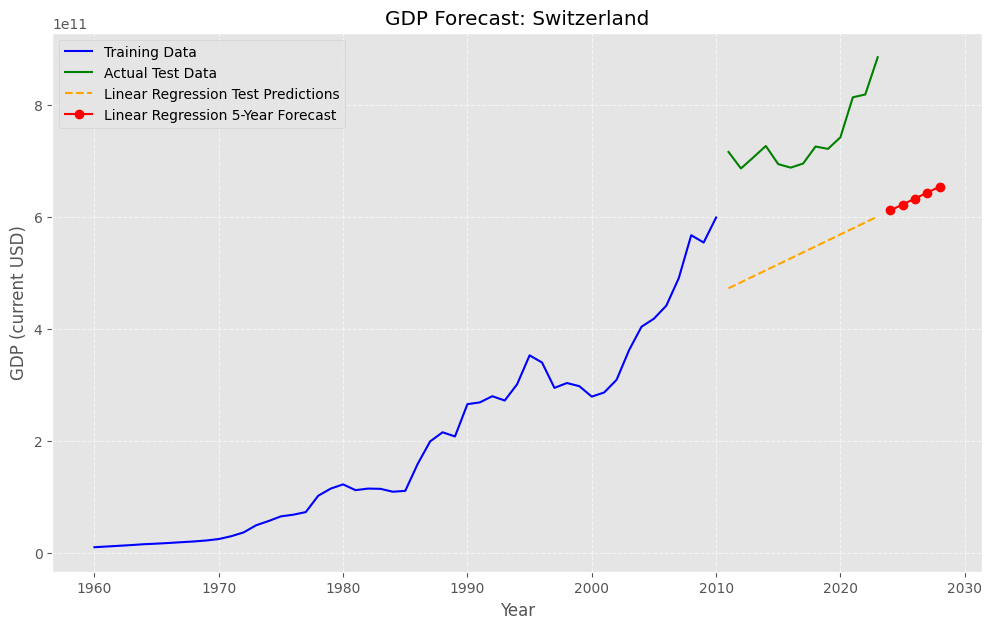

0.2735818847521619

In [ ]:
linear_reg("Switzerland")

Linear Regression Results for European Union:
Mean Squared Error (MSE): 2755371212255372343508992.0000
Mean Absolute Error (MAE): 1366906101250.35
Mean Absolute Percentage Error (MAPE): 8.54%


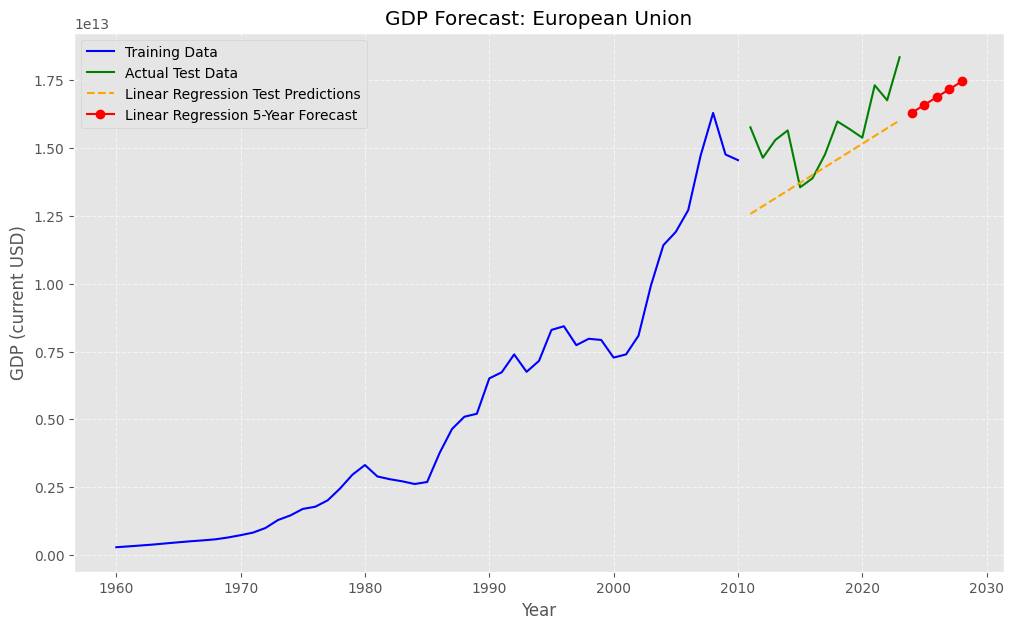

0.08537679040962548

In [ ]:
linear_reg("European Union")

## Polynomial Regression

In [ ]:
def poly(country, plot=True):
  df_poly = df[df['Country Name'] == country].copy()
  df_poly = df_poly.sort_values(by='Year')
  # We use the numeric year for the regression features
  X = df_poly[['Year']].values
  y = df_poly['Value'].values

  train_size = int(len(df_poly) * 0.8)
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]


  degrees = range(2, 6)
  best_score = float('inf')
  optimal_degree = 1

  for d in degrees:
      pipeline = Pipeline([
          ('poly', PolynomialFeatures(degree=d)),
          ('model', LinearRegression())
      ])
      # Negative MSE because cross_val_score maximises by default
      cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
      mean_mse = -cv_scores.mean()
      if mean_mse < best_score:
          best_score = mean_mse
          optimal_degree = d

  print(f"Optimal Polynomial Degree for {country}: {optimal_degree}")

  pf_final = PolynomialFeatures(degree=optimal_degree)
  X_poly_train_final = pf_final.fit_transform(X_train)
  final_model = LinearRegression()
  final_model.fit(X_poly_train_final, y_train)
  y_pred_final = final_model.predict(pf_final.transform(X_test))

  poly_mape = mean_absolute_percentage_error(y_test, y_pred_final)

  if plot:
    mse = mean_squared_error(y_test, y_pred_final)
    mae = mean_absolute_error(y_test, y_pred_final)
    print(f"Polynomial Regression Results for {country} (Degree {optimal_degree}):")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {poly_mape*100:.2f}%")

    last_year = int(X.max())
    future_years = np.arange(last_year + 1, last_year + 6).reshape(-1, 1)
    future_forecast = final_model.predict(pf_final.transform(future_years))

    plt.figure(figsize=(12, 7))
    plt.plot(X_train, y_train, label='Training Data', color='blue')
    plt.plot(X_test, y_test, label='Actual Test Data', color='green')
    plt.plot(X_test, y_pred_final, label='Polynomial Regression Test Predictions', color='orange', linestyle='--')
    plt.plot(future_years, future_forecast, label='Polynomial Regression 5-Year Forecast', color='red', linestyle='-', marker='o')

    plt.title(f"GDP Forecast: {country} (Polynomial Regression - Degree {optimal_degree})")
    plt.xlabel("Year")
    plt.ylabel("GDP (current USD)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    from matplotlib.ticker import FuncFormatter
    def trillions(x, pos):
        return f'${x*1e-12:.1f}T'
    plt.gca().yaxis.set_major_formatter(FuncFormatter(trillions))
    plt.show()

  return poly_mape

Optimal Polynomial Degree for United States: 2
Polynomial Regression Results for United States (Degree 2):
Mean Squared Error (MSE): 1142521402486347869978624.0000
Mean Absolute Error (MAE): 844748081518.77
Mean Absolute Percentage Error (MAPE): 3.98%


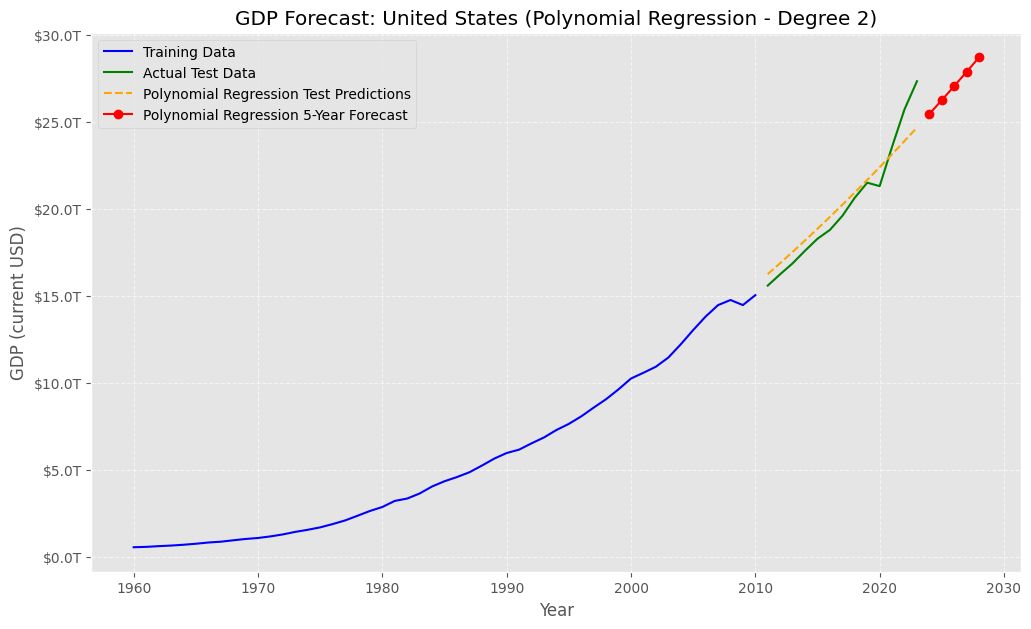

0.03981290776358347

In [ ]:
poly("United States")

Optimal Polynomial Degree for Switzerland: 2
Polynomial Regression Results for Switzerland (Degree 2):
Mean Squared Error (MSE): 4927008946880253001728.0000
Mean Absolute Error (MAE): 52154580426.21
Mean Absolute Percentage Error (MAPE): 7.20%


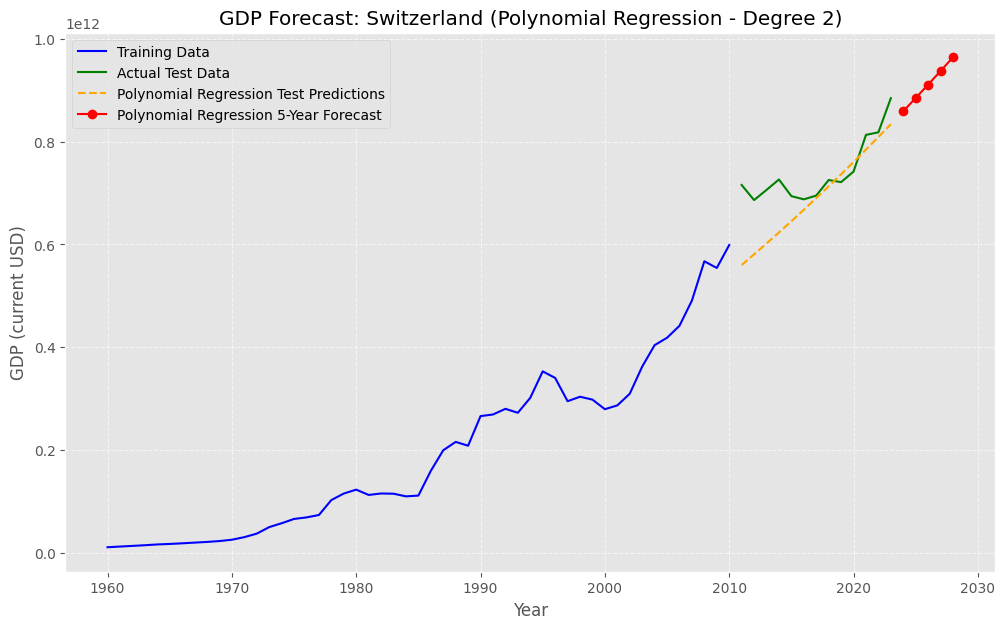

0.07196580108066768

In [ ]:
poly("Switzerland")

Optimal Polynomial Degree for European Union: 2
Polynomial Regression Results for European Union (Degree 2):
Mean Squared Error (MSE): 17830147990607210366369792.0000
Mean Absolute Error (MAE): 3795978957422.61
Mean Absolute Percentage Error (MAPE): 24.28%


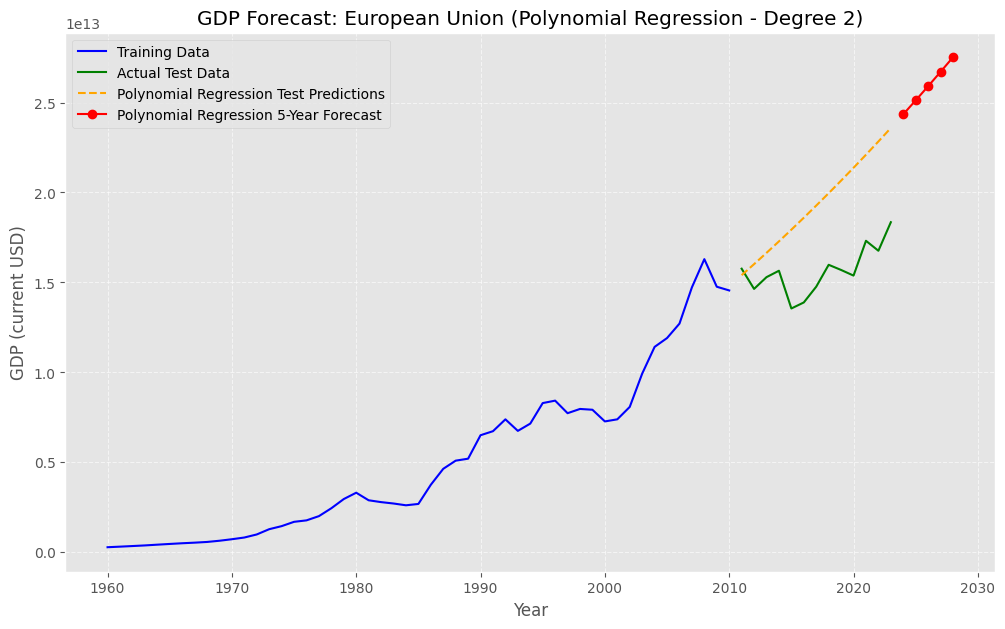

0.24276505418393932

In [ ]:
poly("European Union")

## ARIMA

In [ ]:
def arima(country, plot=True):
  df_arima= df[df['Country Name'] == country].copy()
  df_arima = df_arima.sort_values(by='Year')
  df_arima['Year'] = pd.to_datetime(df_arima['Year'], format='%Y')
  ts = df_arima.set_index('Year')['Value']

  train_size = int(len(ts) * 0.8)
  train_data, test_data = ts.iloc[:train_size], ts.iloc[train_size:]
  # Fixed: pass ranges instead of single integers
  order = optimize_arima(country, range(0, 6), range(0, 3), range(0, 6))
  arima_model = ARIMA(train_data, order=order)
  arima_fit = arima_model.fit(method_kwargs={"warn_convergence": False})

  # Predict on the test set
  start_index = len(train_data)
  end_index = len(ts) - 1
  y_pred_arima = arima_fit.predict(start=start_index, end=end_index, typ='levels')
  mape_arima = mean_absolute_percentage_error(test_data, y_pred_arima)

  if plot:
    mse_arima = mean_squared_error(test_data, y_pred_arima)
    mae_arima = mean_absolute_error(test_data, y_pred_arima)
    print(f"ARIMA Results for {country}:")
    print(f"Mean Squared Error (MSE): {mse_arima:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_arima:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape_arima*100:.2f}%")

    future_forecast_start_index = len(ts)
    future_forecast_end_index = len(ts) + 4
    future_forecast = arima_fit.predict(start=future_forecast_start_index,
                                                  end=future_forecast_end_index,
                                                  typ = 'levels')
    forecast_years = pd.to_datetime(np.arange(ts.index.max().year + 1, ts.index.max().year + 6), format='%Y')
    plt.figure(figsize=(12, 7))
    plt.plot(train_data.index, train_data.values, label='Training Data', color='blue')
    plt.plot(test_data.index, test_data.values, label='Actual Test Data', color='green')
    plt.plot(y_pred_arima.index, y_pred_arima.values, label='ARIMA Test Predictions', color='orange', linestyle='--')
    plt.plot(forecast_years, future_forecast.values, label='ARIMA 5-Year Forecast', color='red', linestyle='-', marker='o')

    plt.title(f"GDP Forecast: {country} (ARIMA)")
    plt.xlabel("Year")
    plt.ylabel("GDP (current USD)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    from matplotlib.ticker import FuncFormatter
    def trillions(x, pos):
        return f'${x*1e-12:.2f}T'
    plt.gca().yaxis.set_major_formatter(FuncFormatter(trillions))
    plt.show()

  return mape_arima


from sklearn.model_selection import ParameterGrid
def optimize_arima(name, p_range, d_range, q_range):
  df_arima = df[df['Country Name'] == name].copy()
  df_arima = df_arima.sort_values(by='Year')

  # Convert Year to datetime and set as index
  df_arima['Year'] = pd.to_datetime(df_arima['Year'], format='%Y')
  ts = df_arima.set_index('Year')['Value']

  # Split data for training and validation
  train_size = int(len(ts) * 0.8)
  train_data = ts.iloc[:train_size]
  test_data = ts.iloc[train_size:]

  best_mae = float('inf')
  best_order = (0, 0, 0)

  print(f"\nOptimizing ARIMA for {name}...")

  # Grid search for p, d, q
  for p in p_range:
    for d in d_range:
      for q in q_range:
        try:
          order = (p, d, q)
          model = ARIMA(train_data, order=order)
          model_fit = model.fit()

          # Make predictions on the test set
          start_index_pred = len(train_data)
          end_index_pred = len(ts) - 1
          y_pred = model_fit.predict(start=start_index_pred, end=end_index_pred, typ='levels')

          mae = mean_absolute_error(test_data, y_pred)

          if mae < best_mae:
            best_mae = mae
            best_order = order
        except:
          continue

  print(f"Best ARIMA Order found: {best_order}")
  return best_order


Optimizing ARIMA for United States...
Best ARIMA Order found: (3, 2, 4)
ARIMA Results for United States:
Mean Squared Error (MSE): 2207471826709002080747520.0000
Mean Absolute Error (MAE): 963321847111.35
Mean Absolute Percentage Error (MAPE): 4.22%


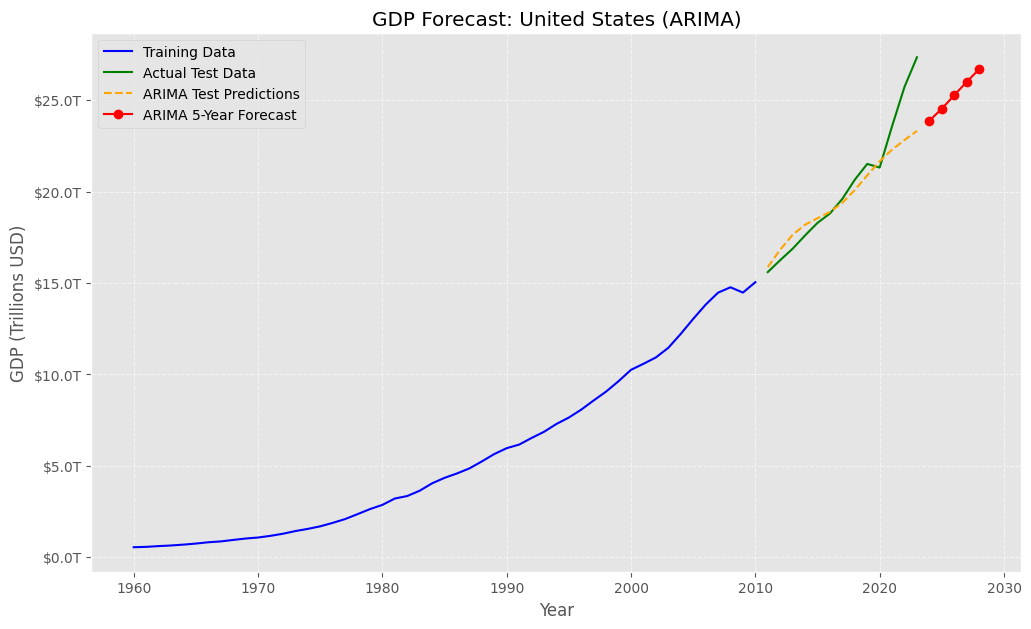

0.042199616192597586

In [ ]:
arima("United States")


Optimizing ARIMA for European Union...
Best ARIMA Order found: (2, 2, 0)
ARIMA Results for European Union:
Mean Squared Error (MSE): 1387840137747818579230720.0000
Mean Absolute Error (MAE): 877964602590.02
Mean Absolute Percentage Error (MAPE): 5.87%


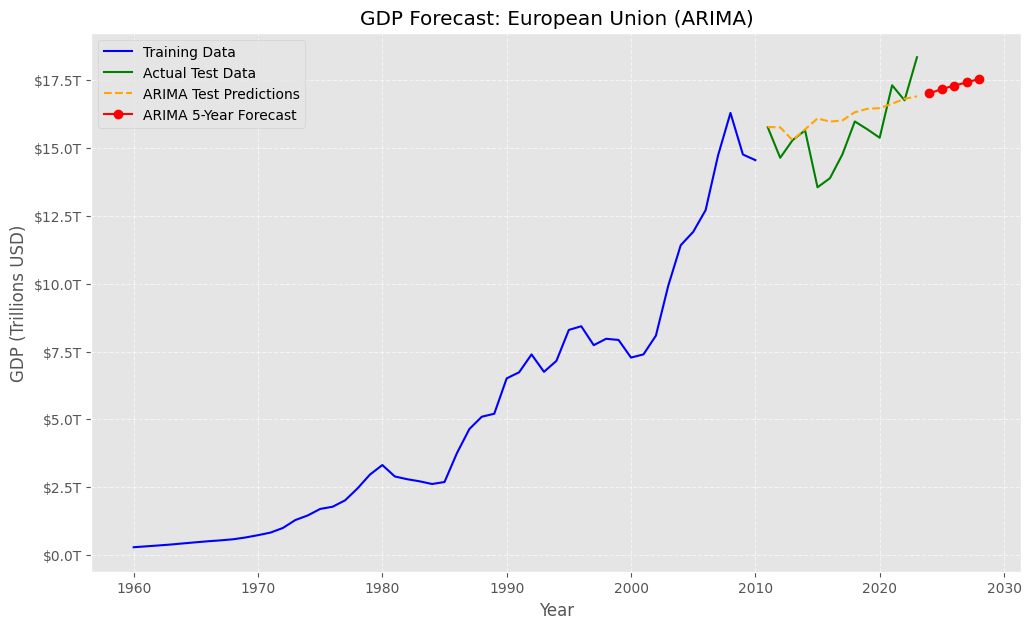

0.05874702780984885

In [ ]:
arima("European Union")


Optimizing ARIMA for Switzerland...
Best ARIMA Order found: (5, 2, 3)
ARIMA Results for Switzerland:
Mean Squared Error (MSE): 2042754871867543126016.0000
Mean Absolute Error (MAE): 38028189286.09
Mean Absolute Percentage Error (MAPE): 5.18%


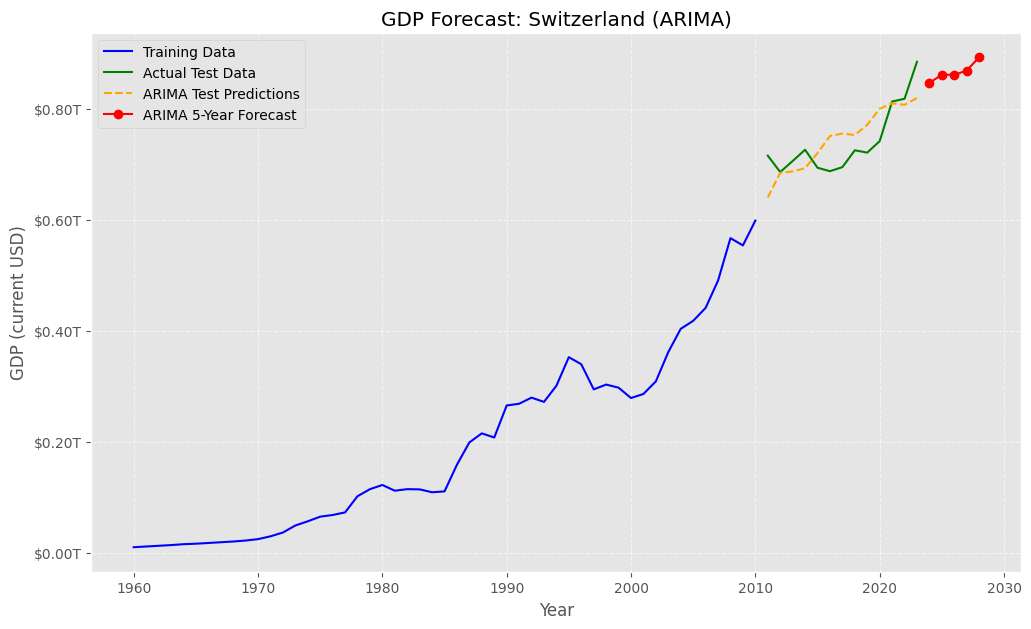

0.051837362084394274

In [ ]:
arima('Switzerland')

## Prophet

In [ ]:
def prophet(country, plot=True):
  prophet_df_raw = df[df["Country Name"] == country].copy()
  prophet_df_raw = prophet_df_raw.sort_values(by='Year')

  prophet_data = pd.DataFrame()
  prophet_data['ds'] = pd.to_datetime(prophet_df_raw['Year'], format='%Y')
  prophet_data['y'] = prophet_df_raw['Value']

  train_size = int(len(prophet_data) * 0.8)
  train_data = prophet_data.iloc[:train_size]
  test_data = prophet_data.iloc[train_size:]


  model = Prophet(
      yearly_seasonality=False,
      weekly_seasonality=False,
      daily_seasonality=False,
      changepoint_prior_scale=0.05
  )
  model.fit(train_data)

  test_future = model.make_future_dataframe(periods=len(test_data), freq='YS')
  test_forecast = model.predict(test_future)
  y_pred_prophet = test_forecast[test_forecast['ds'].isin(test_data['ds'])]['yhat']
  mape_prophet = mean_absolute_percentage_error(test_data['y'].values, y_pred_prophet.values)

  if plot:
    mse_prophet = mean_squared_error(test_data['y'].values, y_pred_prophet.values)
    mae_prophet = mean_absolute_error(test_data['y'].values, y_pred_prophet.values)

    print(f"Prophet Results for {country}:")
    print(f"Mean Squared Error (MSE): {mse_prophet:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_prophet:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape_prophet*100:.2f}%")

    last_year = prophet_data['ds'].max()
    future_years = pd.DataFrame({
        'ds': pd.date_range(start=last_year + pd.DateOffset(years=1), periods=5, freq='YS')
    })
    future_forecast = model.predict(future_years)

    plt.figure(figsize=(12, 7))
    plt.plot(train_data['ds'], train_data['y'], label='Training Data', color='blue')
    plt.plot(test_data['ds'], test_data['y'], label='Actual Test Data', color='green')
    plt.plot(test_data['ds'], y_pred_prophet.values, label='Prophet Test Predictions', color='orange', linestyle='--')
    plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Prophet 5-Year Forecast', color='red', linestyle='-', marker='o')
    plt.title(f"GDP Forecast: {country} (Prophet)")
    plt.xlabel("Year")
    plt.ylabel("GDP (current USD)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    from matplotlib.ticker import FuncFormatter
    def trillions(x, pos):
        return f'${x*1e-12:.1f}T'
    plt.gca().yaxis.set_major_formatter(FuncFormatter(trillions))
    plt.show()

  return mape_prophet

Prophet Results for United States:
Mean Squared Error (MSE): 3909180863518501662359552.0000
Mean Absolute Error (MAE): 1236521200719.82
Mean Absolute Percentage Error (MAPE): 5.21%


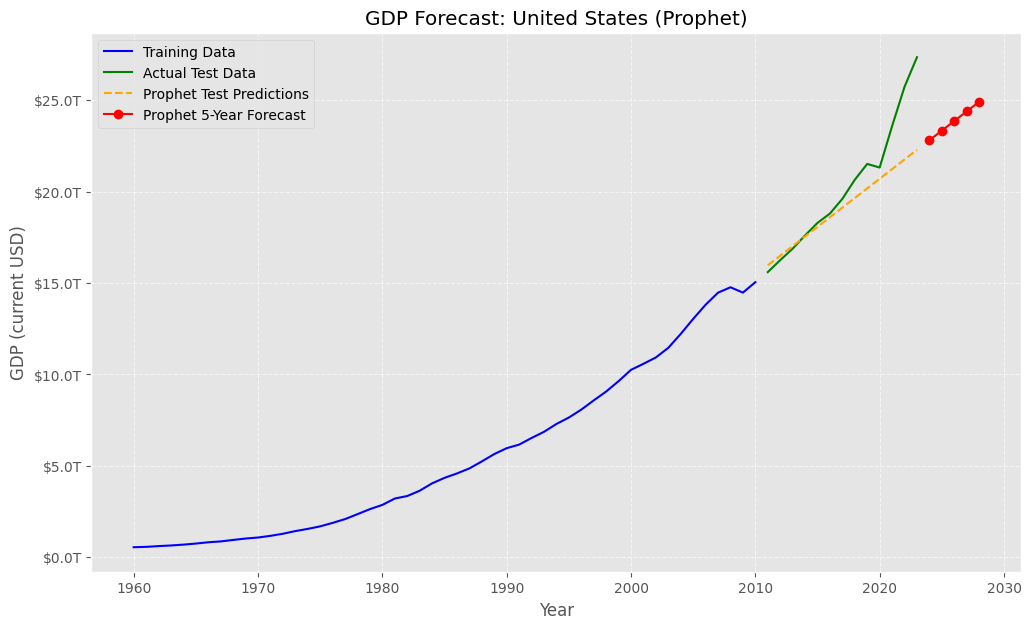

0.05206260938920736

In [ ]:
prophet("United States")

Prophet Results for Switzerland:
Mean Squared Error (MSE): 23710251934155699912704.0000
Mean Absolute Error (MAE): 149588427454.74
Mean Absolute Percentage Error (MAPE): 20.15%


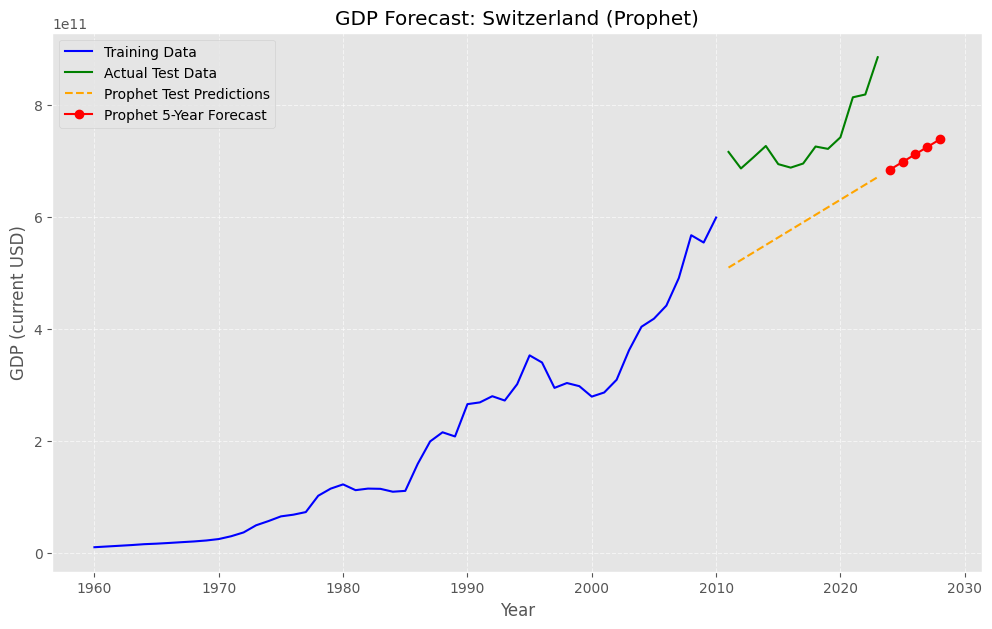

0.201524592708968

In [ ]:
prophet("Switzerland")

Prophet Results for European Union:
Mean Squared Error (MSE): 1807928029173909125332992.0000
Mean Absolute Error (MAE): 1167828151404.70
Mean Absolute Percentage Error (MAPE): 7.71%


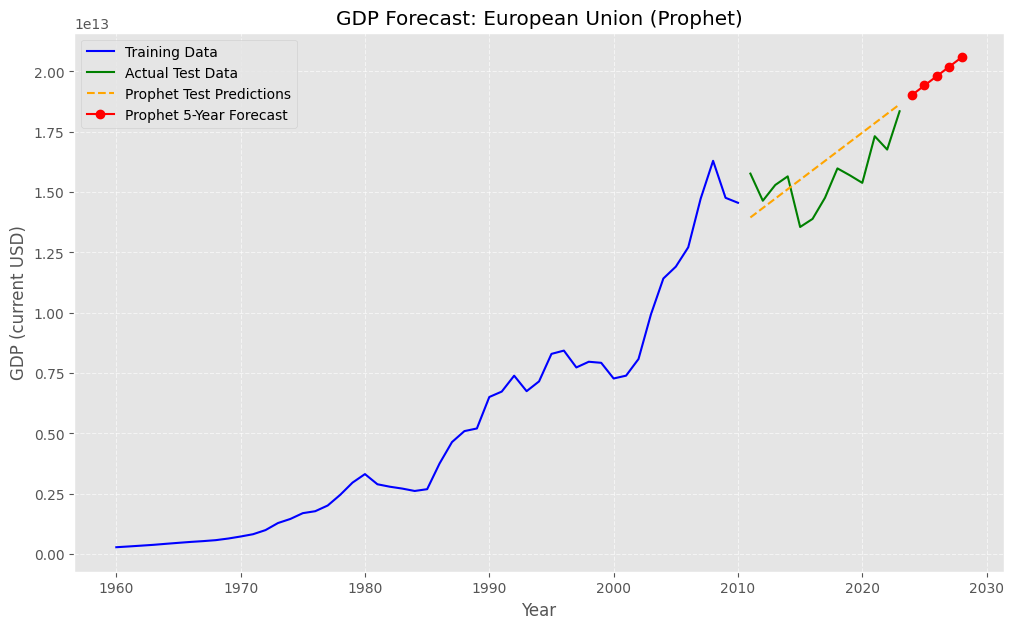

0.07705696245105241

In [ ]:
prophet("European Union")

##Model Comparisons for each country

Optimal Polynomial Degree for United States: 2

Optimizing ARIMA for United States...
Best ARIMA Order found: (3, 2, 4)

MODEL COMPARISON
           Model     MAPE
Polynomial Trend 0.039813
           ARIMA 0.042200
         Prophet 0.052063
    Linear Trend 0.238549

Best Model: Polynomial Trend (MAPE = 0.04)


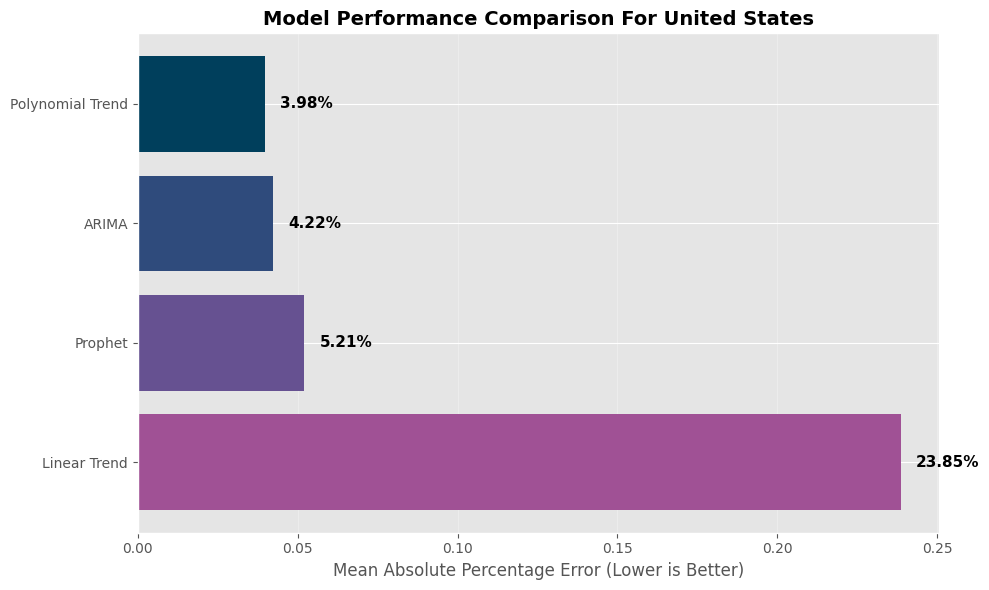

Optimal Polynomial Degree for Switzerland: 2

Optimizing ARIMA for Switzerland...
Best ARIMA Order found: (5, 2, 3)

MODEL COMPARISON
           Model     MAPE
           ARIMA 0.051837
Polynomial Trend 0.071966
         Prophet 0.201525
    Linear Trend 0.273582

Best Model: ARIMA (MAPE = 0.05)


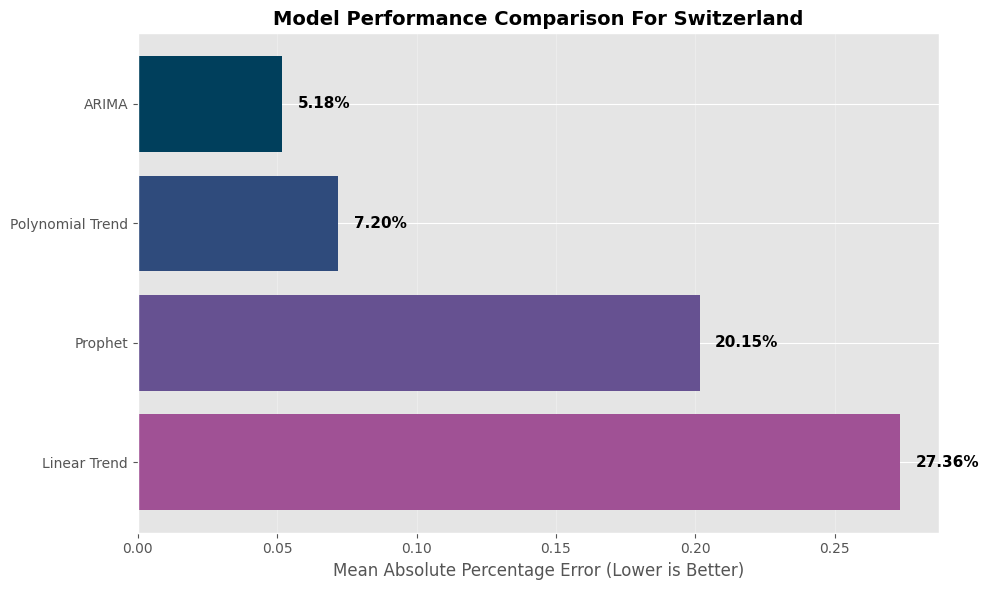

Optimal Polynomial Degree for European Union: 2

Optimizing ARIMA for European Union...
Best ARIMA Order found: (2, 2, 0)

MODEL COMPARISON
           Model     MAPE
           ARIMA 0.058747
         Prophet 0.077057
    Linear Trend 0.085377
Polynomial Trend 0.242765

Best Model: ARIMA (MAPE = 0.06)


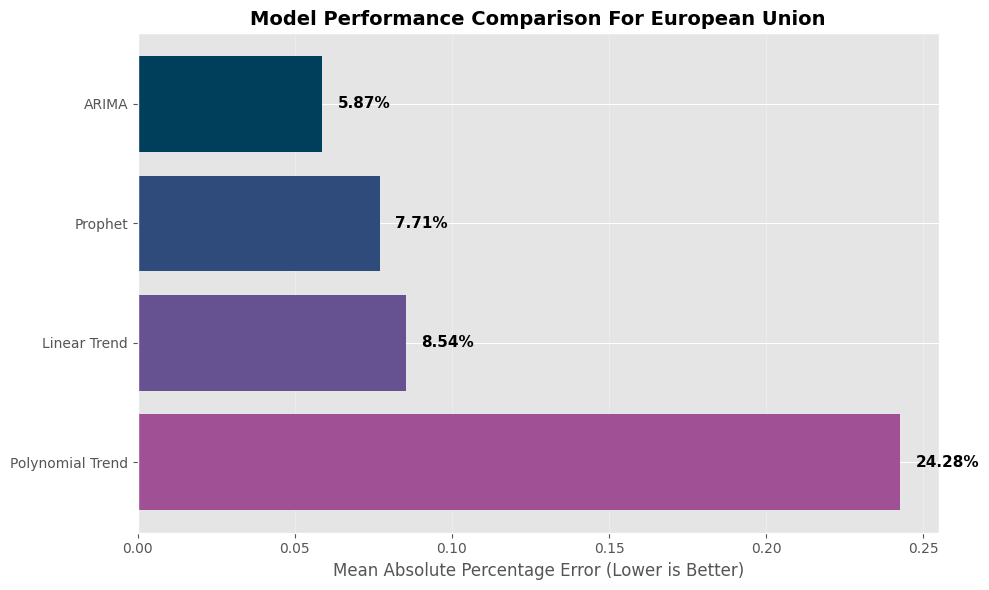

In [ ]:
countries = ['United States', 'Switzerland', 'European Union']
for country in countries:
  results = pd.DataFrame({
      'Model': ['Linear Trend', 'Polynomial Trend', 'ARIMA', 'Prophet'],
      'MAPE': [linear_reg(country, plot=False), poly(country, plot=False),
               arima(country, plot=False), prophet(country, plot=False)]
  })
  results = results.sort_values('MAPE')
  print("\nMODEL COMPARISON")
  print("="*60)
  print(results.to_string(index=False))
  print("="*60)
  print(f"\nBest Model: {results.iloc[0]['Model']} (MAPE = {results.iloc[0]['MAPE']:.2f})")
  # Visualize comparison
  fig, ax = plt.subplots(figsize=(10, 6))
  bars = ax.barh(results['Model'], results['MAPE'], color = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#f95d6a'])
  ax.set_xlabel('Mean Absolute Percentage Error (Lower is Better)', fontsize=12)
  ax.set_title(f'Model Performance Comparison For {country}', fontsize=14, fontweight='bold')
  ax.invert_yaxis()
  ax.grid(True, alpha=0.3, axis='x')

  # Add values on bars
  for i, bar in enumerate(bars):
      width = bar.get_width()
      offset = results['MAPE'].max() * 0.02
      ax.text(width + offset, bar.get_y() + bar.get_height()/2,
              f'{width*100:.2f}%', ha='left', va='center', fontsize=11, fontweight='bold')

  plt.tight_layout()
  plt.show()

## Backtesting

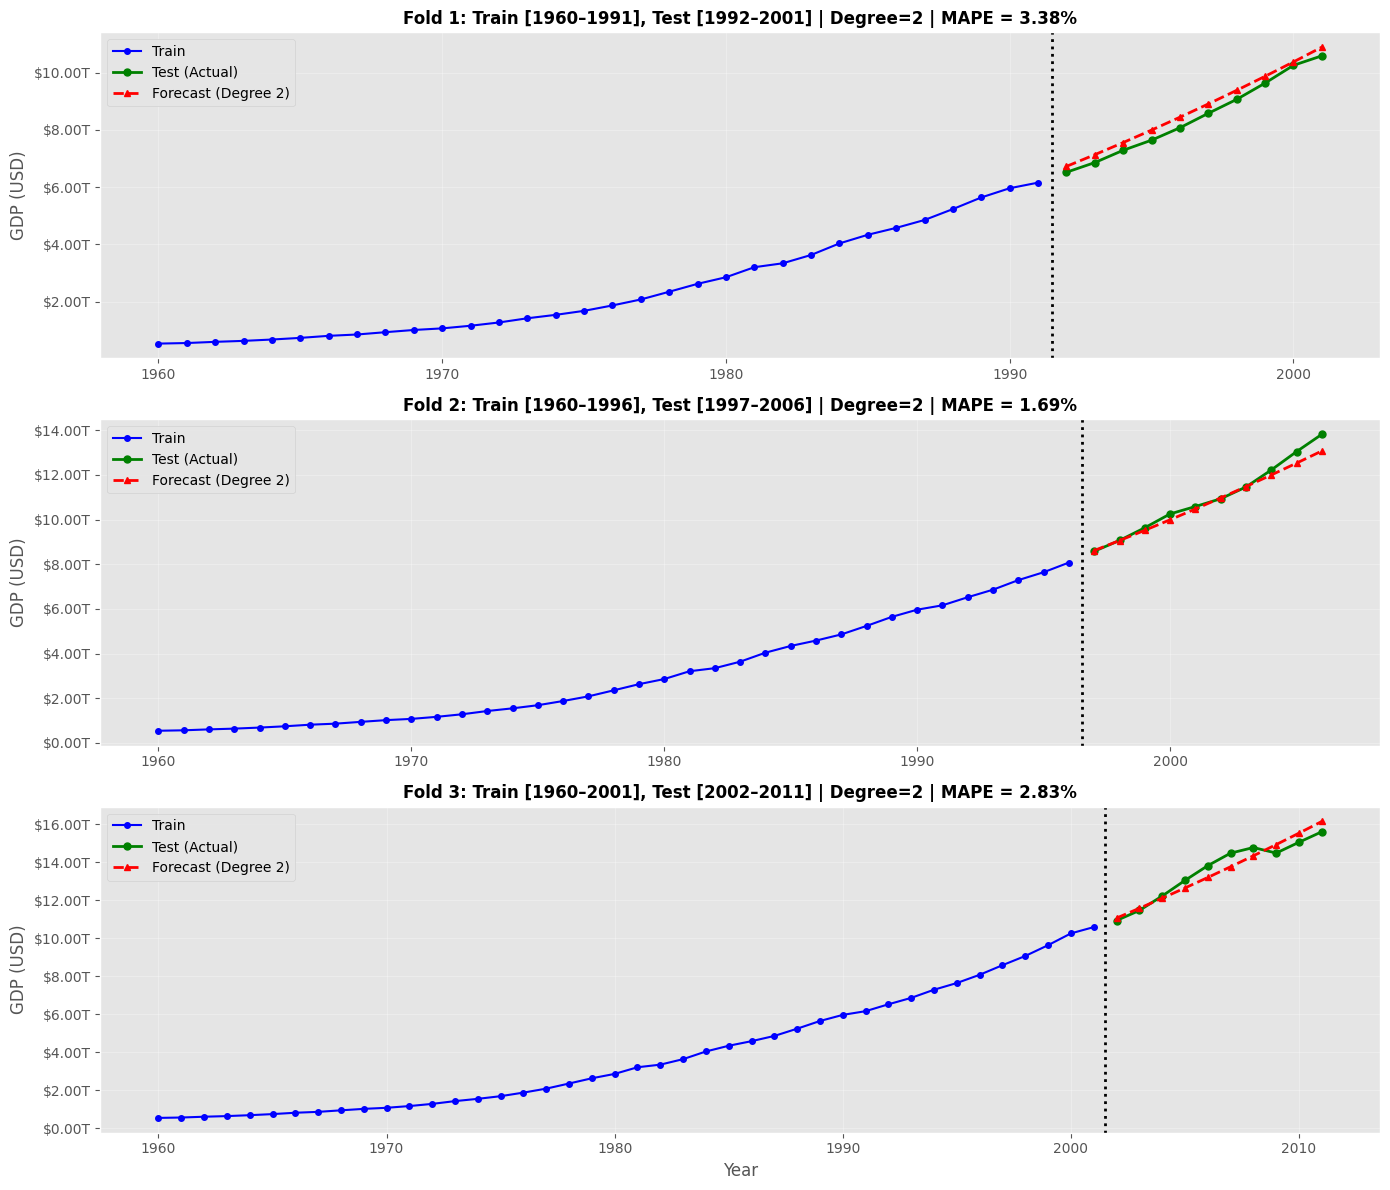


  POLYNOMIAL REGRESSION BACKTESTING RESULTS (United States)
Fold 1 MAPE: 3.38%
Fold 2 MAPE: 1.69%
Fold 3 MAPE: 2.83%
Average MAPE across folds: 2.63%
Std Dev of MAPE:           0.70%

  Backtesting gives us confidence in model stability!
  If MAPE varies wildly across folds, the model might not be robust.


In [ ]:
# Backtesting with Polynomial Regression — rolling windows, fixed test size
test_size = 10
n_folds = 3

# Prepare US GDP data
us_data = df[df['Country Name'] == 'United States'][['Year', 'Value']].sort_values('Year').reset_index(drop=True)
X_all = us_data['Year'].values.reshape(-1, 1)
y_all = us_data['Value'].values

initial_train_size = int(len(us_data) * 0.5)  # Starting training window

fig, axes = plt.subplots(n_folds, 1, figsize=(14, 12))

mape_scores = []

for fold in range(n_folds):
    # Define train/test split for this fold (growing training set, fixed test size)
    train_end = initial_train_size + (fold * 5)  # Expand training by 5 years each fold
    test_start = train_end
    test_end = test_start + test_size

    X_train_fold = X_all[:train_end]
    y_train_fold = y_all[:train_end]
    X_test_fold  = X_all[test_start:test_end]
    y_test_fold  = y_all[test_start:test_end]

    # Find optimal polynomial degree via cross-validation
    best_score = float('inf')
    optimal_degree = 2

    for d in range(2, 6):
        pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=d)),
            ('model', LinearRegression())
        ])
        cv_scores = cross_val_score(pipeline, X_train_fold, y_train_fold, cv=5, scoring='neg_mean_squared_error')
        mean_mse = -cv_scores.mean()
        if mean_mse < best_score:
            best_score = mean_mse
            optimal_degree = d

    # Fit final model with optimal degree
    pf = PolynomialFeatures(degree=optimal_degree)
    X_poly_train = pf.fit_transform(X_train_fold)
    model = LinearRegression()
    model.fit(X_poly_train, y_train_fold)
    predictions_fold = model.predict(pf.transform(X_test_fold))

    # Calculate MAPE
    mape_fold = mean_absolute_percentage_error(y_test_fold, predictions_fold)
    mape_scores.append(mape_fold)

    # Plot
    axes[fold].plot(X_train_fold, y_train_fold, 'o-', label='Train', color='blue', markersize=4)
    axes[fold].plot(X_test_fold, y_test_fold, 'o-', label='Test (Actual)', color='green', markersize=5, linewidth=2)
    axes[fold].plot(X_test_fold, predictions_fold, '^--', label=f'Forecast (Degree {optimal_degree})', color='red', markersize=5, linewidth=2)
    axes[fold].axvline(X_train_fold[-1][0] + 0.5, color='black', linestyle=':', linewidth=2)
    axes[fold].set_title(
        f'Fold {fold+1}: Train [{X_train_fold[0][0]}–{X_train_fold[-1][0]}], '
        f'Test [{X_test_fold[0][0]}–{X_test_fold[-1][0]}] | Degree={optimal_degree} | MAPE = {mape_fold*100:.2f}%',
        fontsize=12, fontweight='bold'
    )
    axes[fold].set_ylabel('GDP (USD)')
    axes[fold].legend(loc='upper left')
    axes[fold].grid(True, alpha=0.3)

    from matplotlib.ticker import FuncFormatter
    def trillions(x, pos):
        return f'${x*1e-12:.2f}T'
    # Fixed: Use the specific axes object for each subplot
    axes[fold].yaxis.set_major_formatter(FuncFormatter(trillions))

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

print("\n  POLYNOMIAL REGRESSION BACKTESTING RESULTS (United States)")
print("="*50)
for i, mape in enumerate(mape_scores):
    print(f"Fold {i+1} MAPE: {mape*100:.2f}%")
print("="*50)
print(f"Average MAPE across folds: {np.mean(mape_scores)*100:.2f}%")
print(f"Std Dev of MAPE:           {np.std(mape_scores)*100:.2f}%")
print("\n  Backtesting gives us confidence in model stability!")
print("  If MAPE varies wildly across folds, the model might not be robust.")

# Correlation Matrix

In [ ]:
countries_list = ['Italy', 'Germany', 'France', 'United Kingdom', 'Canada', 'United States', 'Brazil', 'Japan', 'India', 'China', 'Angola', 'Congo, Dem. Rep.', 'Equatorial Guinea', 'Nigeria', 'Azerbaijan', 'Iraq', 'Oman', 'Saudi Arabia', 'United Arab Emirates']

all_results = []

print("Calculating MAPE scores for all countries (this may take a moment due to ARIMA optimization)...")

for country in countries_list:
    try:
        # Calculate MAPEs using existing functions with plot=False
        m_linear = linear_reg(country, plot=False)
        m_poly = poly(country, plot=False)
        m_arima = arima(country, plot=False)
        m_prophet = prophet(country, plot=False)

        all_results.append({
            'Country': country,
            'Linear MAPE (%)': round(m_linear * 100, 2),
            'Polynomial MAPE (%)': round(m_poly * 100, 2),
            'ARIMA MAPE (%)': round(m_arima * 100, 2),
            'Prophet MAPE (%)': round(m_prophet * 100, 2)
        })
    except Exception as e:
        print(f"Could not process {country}: {e}")

# Create DataFrame
mape_df = pd.DataFrame(all_results)


# Display the table
display(mape_df)

Calculating MAPE scores for all countries (this may take a moment due to ARIMA optimization)...
Optimal Polynomial Degree for Italy: 2

Optimizing ARIMA for Italy...
Best ARIMA Order found: (1, 1, 0)
Optimal Polynomial Degree for Germany: 2

Optimizing ARIMA for Germany...
Best ARIMA Order found: (2, 1, 2)
Optimal Polynomial Degree for France: 2

Optimizing ARIMA for France...
Best ARIMA Order found: (2, 2, 0)
Optimal Polynomial Degree for United Kingdom: 2

Optimizing ARIMA for United Kingdom...
Best ARIMA Order found: (2, 2, 4)
Optimal Polynomial Degree for Canada: 2

Optimizing ARIMA for Canada...
Best ARIMA Order found: (1, 1, 0)
Optimal Polynomial Degree for United States: 2

Optimizing ARIMA for United States...
Best ARIMA Order found: (3, 2, 4)
Optimal Polynomial Degree for Brazil: 2

Optimizing ARIMA for Brazil...


INFO:prophet:n_changepoints greater than number of observations. Using 21.


Best ARIMA Order found: (0, 1, 2)
Optimal Polynomial Degree for Japan: 5

Optimizing ARIMA for Japan...
Best ARIMA Order found: (2, 0, 4)
Optimal Polynomial Degree for India: 2

Optimizing ARIMA for India...
Best ARIMA Order found: (3, 1, 4)
Optimal Polynomial Degree for China: 5

Optimizing ARIMA for China...
Best ARIMA Order found: (2, 1, 2)
Optimal Polynomial Degree for Angola: 2

Optimizing ARIMA for Angola...
Best ARIMA Order found: (4, 1, 3)


INFO:prophet:n_changepoints greater than number of observations. Using 18.


Optimal Polynomial Degree for Congo, Dem. Rep.: 2

Optimizing ARIMA for Congo, Dem. Rep....
Best ARIMA Order found: (4, 2, 4)


INFO:prophet:n_changepoints greater than number of observations. Using 19.


Optimal Polynomial Degree for Equatorial Guinea: 5

Optimizing ARIMA for Equatorial Guinea...
Best ARIMA Order found: (2, 0, 4)
Optimal Polynomial Degree for Nigeria: 2

Optimizing ARIMA for Nigeria...
Best ARIMA Order found: (4, 2, 5)
Optimal Polynomial Degree for Azerbaijan: 2

Optimizing ARIMA for Azerbaijan...


INFO:prophet:n_changepoints greater than number of observations. Using 20.


Best ARIMA Order found: (0, 1, 0)
Optimal Polynomial Degree for Iraq: 2

Optimizing ARIMA for Iraq...
Best ARIMA Order found: (1, 2, 0)
Optimal Polynomial Degree for Oman: 2

Optimizing ARIMA for Oman...
Best ARIMA Order found: (3, 0, 0)
Optimal Polynomial Degree for Saudi Arabia: 2

Optimizing ARIMA for Saudi Arabia...
Best ARIMA Order found: (0, 2, 2)
Optimal Polynomial Degree for United Arab Emirates: 5

Optimizing ARIMA for United Arab Emirates...
Best ARIMA Order found: (2, 1, 0)


,Country,Linear MAPE (%),Polynomial MAPE (%),ARIMA MAPE (%),Prophet MAPE (%)
0,Italy,12.36,41.05,5.55,20.46
1,Germany,6.56,15.72,4.60,5.21
2,France,6.73,26.75,5.14,11.41
3,United Kingdom,6.33,34.21,4.94,15.72
4,Canada,24.65,13.34,8.43,17.62
5,United States,23.85,3.98,4.22,5.21
6,Brazil,37.39,73.58,9.53,37.67
7,Japan,34.48,34.69,7.08,34.54
8,India,59.07,32.99,5.45,58.86
9,China,75.48,22.62,4.01,75.47


In [ ]:
corr_df = pd.merge(volatility_top_10_gdp, volatility_top_10, how='outer')

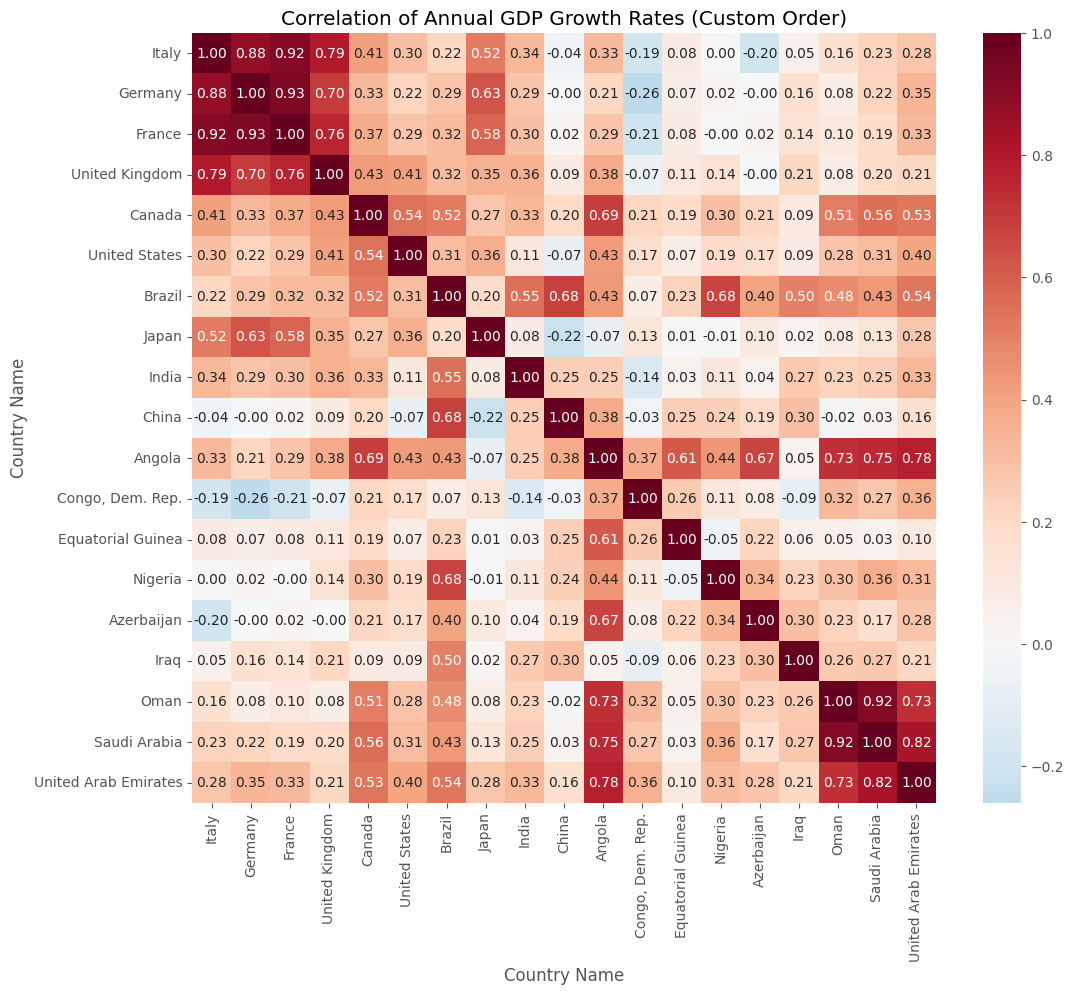

,Country Name,Volatility
0,Italy,10.715690
1,Germany,10.940162
2,France,10.577643
3,United Kingdom,9.821913
4,Canada,7.345256


In [ ]:
custom order = ['Japan', 'India', 'China', 'Angola', 'Congo, Dem. Rep.', 'Equatorial Guinea', 'Nigeria', 'Azerbaijan',
                'Iraq', 'Oman', 'Saudi Arabia', 'United Arab Emirates']
corr_df_reordered = corr_df.set_index('Country Name').reindex(custom_order).reset_index()
countries_of_interest = custom_order
growth_pivot_reordered = df_growth[df_growth['Country Name'].isin(countries_of_interest)].pivot(index='Year', columns='Country Name', values='Growth_Rate')
growth_pivot_reordered = growth_pivot_reordered[custom_order]

country_growth_corr_reordered = growth_pivot_reordered.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(country_growth_corr_reordered, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation of Annual GDP Growth Rates (Custom Order)')
plt.show()

display(corr_df_reordered.head())